# Time Evolution of Quantum Spin Chains: Exact Diagonalisation and Qiskit Trotter Simulation

**Course:** PH10110 - Quantum Computing Group Project  
**Date:** March 2026  

---

## Abstract

We study the real-time dynamics of the one-dimensional anisotropic Heisenberg (XXZ) spin chain
by comparing three simulation strategies of increasing realism:
(i) exact sparse-matrix time evolution via the matrix exponential,
(ii) ideal first- and second-order Qiskit Trotter-Suzuki circuits simulated with `Statevector`, and
(iii) noisy Qiskit Trotter circuits simulated with `AerSimulator` in density-matrix mode using a
noise model derived from a real IBM QPU's calibration data via `NoiseModel.from_backend()`.
For an $L = 8$ site chain with open boundary conditions, we characterise
the space-time magnetisation dynamics and the two-dimensional Fourier spectrum of the
$\langle Z_i(t)\rangle$ observable. We quantify the Trotter approximation error as a function
of the number of time steps, confirming the expected $\mathcal{O}(\Delta t^p)$ convergence
for $p$-th order product formulas. The noisy Aer simulations, based on the calibration data of
`ibm_fez`, demonstrate that realistic device noise significantly degrades the long-time fidelity
of the evolution, illustrating both the utility of quantum-circuit simulation and the current
sensitivity of many-body dynamics to hardware imperfections.

## Table of Contents

1. [Introduction](#1-introduction)
2. [Problem Formulation and Theoretical Background](#2-problem-formulation-and-theoretical-background)
3. [Methods](#3-methods)
4. [Implementation Details](#4-implementation-details)
5. [Classical Benchmarks: Exact Diagonalisation](#5-classical-benchmarks-exact-diagonalisation)
6. [Quantum Simulation Results: Trotter Decomposition](#6-quantum-simulation-results-trotter-decomposition)
7. [Noisy Simulation Results](#7-noisy-simulation-results)
8. [Error Scaling Analysis](#8-error-scaling-analysis)
9. [Spectral Analysis](#9-spectral-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)
12. [Contribution Statement](#12-contribution-statement)
13. [References](#13-references)

## 1. Introduction

<a id="1-introduction"></a>

Simulating the time evolution of quantum many-body systems is one of the most promising
near-term applications of quantum computing [1, 2]. The central difficulty is that the
Hilbert-space dimension grows exponentially with the number of particles: for $L$ spin-$\tfrac{1}{2}$
sites the state vector has $2^L$ complex amplitudes, making classical simulation intractable
beyond $L \approx 40$-50 even on modern supercomputers.

Quantum computers bypass this exponential barrier by encoding the $2^L$-dimensional state
in only $L$ qubits. Feynman's original insight [3] was precisely that a controllable quantum
system could simulate another quantum system efficiently. Since then, Lloyd showed that
local Hamiltonians can be simulated in polynomial time using product-formula (Trotter)
decompositions [4], and this remains one of the best-understood quantum-simulation
algorithms.

**The physical system** we study is the one-dimensional XXZ Heisenberg spin chain, a
paradigmatic model in condensed-matter physics that captures the competition between
exchange interactions and Ising anisotropy. It exhibits a rich phase diagram including
gapless Luttinger-liquid, ferromagnetic, and antiferromagnetic Neel phases depending on the
anisotropy parameter $J_z$.

**Project objective.** The aim of this project is threefold:

1. **Benchmark exact classical simulation** of the XXZ model for $L = 8$ spins, including
   space-time magnetisation maps and spectral analysis.
2. **Implement and validate Qiskit Trotter-Suzuki circuits** for the time-evolution operator,
   comparing first- and second-order product formulae against exact results.
3. **Assess the impact of gate-level noise** by simulating the same Trotter circuits with a
   Qiskit Aer noise model, and comparing the noisy circuit dynamics to both the exact and ideal
   quantum-circuit results.

By comparing these three levels of simulation we can draw conclusions about when quantum
hardware-inspired circuit models capture the correct many-body dynamics, and where noise
becomes the dominant limitation.

**Why quantum computers are relevant.** For $L = 8$, exact classical simulation is
straightforward (the Hilbert space has dimension $2^8 = 256$), so there is no quantum
advantage at this system size. The value of this study is pedagogical and methodological:
we validate the quantum algorithms at a size where exact benchmarking is possible, before
extrapolating to the $L \gtrsim 50$ regime where classical methods fail and quantum
advantage becomes genuine. We discuss the scaling implications in Section 10.

## 2. Problem Formulation and Theoretical Background

<a id="2-problem-formulation-and-theoretical-background"></a>

### 2.1 The XXZ Heisenberg Hamiltonian

The one-dimensional XXZ model on $L$ sites with open boundary conditions reads

$$
H = -\sum_{\langle i,j \rangle}
    \bigl(\sigma_i^x \sigma_j^x + \sigma_i^y \sigma_j^y + J_z\,\sigma_i^z \sigma_j^z\bigr),
\tag{1}
$$

where $\sigma_i^\alpha$ ($\alpha \in \{x,y,z\}$) are the Pauli matrices acting on site $i$,
and the sum runs over nearest-neighbour pairs $\langle i,j \rangle$.  The dimensionless
coupling $J_z$ controls the Ising anisotropy:

| Regime | $J_z$ range | Physical character |
|--------|-------------|--------------------|
| Ferromagnetic | $J_z > 1$ | Ising-like, spins prefer alignment |
| Isotropic (XXX) | $J_z = 1$ | Full $SU(2)$ symmetry |
| Critical (XY-like) | $-1 < J_z < 1$ | Gapless Luttinger liquid |
| Antiferromagnetic Néel | $J_z < -1$ | Alternating spin order |

In this project we study three representative cases:

- **Case A:** $J_z = 1.5$ (ferromagnetic), initial state all spins down ($|00\ldots 0\rangle$) with one spin rotated to the equator.
- **Case B:** $J_z = 1.5$ (ferromagnetic), initial state all spins up ($|11\ldots 1\rangle$) with one spin rotated.
- **Case C:** $J_z = -1.5$ (antiferromagnetic Néel), alternating initial state ($|1010\ldots\rangle$) with one spin rotated.

### 2.2 Time Evolution

The state of the system at time $t$ is given by the Schrödinger-picture evolution

$$
|\psi(t)\rangle = e^{-iHt}\,|\psi(0)\rangle,
\tag{2}
$$

where we set $\hbar = 1$.  Computing $e^{-iHt}$ exactly requires diagonalising the $2^L \times 2^L$
Hamiltonian matrix, which costs $\mathcal{O}(2^{3L})$ in general.  For our system size $L = 8$
($\mathrm{dim} = 256$), the matrix exponential `scipy.linalg.expm` is efficient enough
to serve as an exact benchmark.

### 2.3 Initial-State Preparation

Each simulation case starts from a product state (a computational basis state) with a
single-site rotation that creates a local superposition.  For a site initially in $|0\rangle$,
we apply

$$
|\psi_{\mathrm{site}}\rangle = R_z(\phi)\,H\,|0\rangle
    = R_z(\phi)\,|+\rangle
    = \frac{1}{\sqrt{2}}\bigl(e^{-i\phi/2}|0\rangle + e^{+i\phi/2}|1\rangle\bigr),
\tag{3}
$$

with $\phi = \pi/3$.  This places the spin on the Bloch-sphere equator, breaking the $Z$
symmetry and generating non-trivial dynamics under $H$.

### 2.4 Observables

We track the local expectation values $\langle\sigma_i^\alpha(t)\rangle$ for
$\alpha \in \{X, Y, Z\}$ and all sites $i \in \{0, \ldots, L-1\}$.  These define a
space–time observable map of dimension $(n_t \times L \times 3)$.

The two-dimensional discrete Fourier transform of $\langle Z_i(t)\rangle$ yields the
momentum–frequency spectrum, allowing identification of the dispersion relation and
collective excitations of the spin chain.

## 3. Methods

<a id="3-methods"></a>

### 3.1 Exact Diagonalisation (Classical Benchmark)

For any integer number of qubits $L$, the Hamiltonian is represented as a $2^L \times 2^L$ matrix. In theory, one could diagonalise the 
initial Hamiltonian using standard eigenvalue/eigenvector decomposition and use the Maclaurin expansion of the
exponential of the matrix to evaluate the unitary operator's matrix. The issue with this is that it becomes highly impractical incredibly fast, 
thus it is more practical to implement the circuit computationally in almost all cases. The Hamiltonian is constructed by summing 
two-site Kronecker-product terms (Eq. 1) using SciPy sparse matrices. Then the time-evolved states' exponential
representation $U(\Delta t) = e^{-iH\Delta t}$ are computed using `scipy.linalg.expm`. Assuming the simplest
model of complexity where we require just $2^{2L}$ classical bits for each equivalent $L$-qubit Hamiltonian, 
this quickly scales: at $L=4$, the Hamiltonian is on the order of Bytes; at $L=8$, this increases to 
KBs, and by a simple case of $L=24$, the memory required is on the order of TBs. Thus this method is only suitable 
for small qubit systems.

### 3.2 Trotter-Suzuki Decomposition in Qiskit

The product-formula approach approximates the global evolution operator by splitting it into a sequence of 
local two-site unitaries. Writing $H = \sum_b H_b$ where $b$ labels nearest-neighbour bonds, we have:

**First-order Trotter:**
$$
e^{-iH\Delta t} \approx \prod_{b} e^{-iH_b\Delta t} + \mathcal{O}(\Delta t^2).
\tag{4}
$$

In the Qiskit implementation of the circuit, each XXZ two-site factor is decomposed explicitly into native `rxx`, `ryy`, 
and `rzz` gates. This is because the unitary gate can be very easily derived using `rxx`, `ryy`, and `rzz` 
gates [11]:

$$
\begin{align*}
U_{\Delta t} &= \exp \left(-i \left(-\sum_{\langle i,j \rangle} (X_i \otimes X_j + Y_i \otimes Y_j + J_z Z_i 
\otimes Z_j ) \right) \Delta t \right) \\

&= \prod_{\langle i,j \rangle} e^{\left( i X_i \otimes X_j  \Delta t  \right)} e^{\left( i Y_i \otimes Y_j  
\Delta t \right)} e^{\left( i J_z Z_i \otimes Z_j \Delta t \right)} \because \text{ Trotter} \\

&= \prod_{\langle i,j \rangle} R_{XX}(-2\Delta t) R_{YY}(-2\Delta t) R_{ZZ}(-2 J_Z \Delta t) \because 
R_{XX}(\theta) = \exp\left({-i\frac{\theta}{2}X \otimes X}\right)
\end{align*}
$$

This is easily implemented as a unitary operator in the circuit as can be seen in this circuit diagram for $L=4, \Delta t = 0.2, J_Z=-1.5$.
<p align="center">
    <img title="Unitary Operator with Paired Rotation Gates" alt="A quantum circuit diagram representing the unitary operator derived above with RXX, RYY, and RZZ gates" src="unitary.jpeg" height=250>
</p>

It is important to note that the gates do produce entanglement. The unitary *structure* does not change under 
different universal sets but the RXX, RYY, and RZZ gates are different under the universal states. Below is 
the same unitary operator $U_{\Delta t}$ utilising the universal set for the IBM hardware ($CNOT, H, Rz, X \text{ and } \sqrt{X}$):

<p align="center">
    <img title="Decomposed Unitary Operator" alt="A quantum circuit diagram representing the unitary operator derived above with the IBM universal quantum gates set" src="unitary_decomposed.jpeg" height=450>
</p>

**Why Trotter decomposition is appropriate:** it is the simplest product-formula method,
well-understood theoretically, and directly expressible as a quantum circuit. Its error is
controllable: by increasing the number of Trotter steps $n$ (decreasing $\Delta t = T/n$),
the approximation converges to the exact evolution.

The Trotter decomposition simulation is incredibly simple. It follows the algorithm [10]:
$$
\begin{alignat*}{2}
&1. |\tilde{\psi}_0 \rangle \gets |\psi_0 \rangle; j=0 &\text{ initialise state}\\
&2. \to |\tilde{\psi}_{j+1}\rangle = U_{\Delta t} |\tilde{\psi}_{j}\rangle &\text{ iterative update} \\
&3. \to j=j+1; \text{ go to 2. until }  j\Delta t \geq t_f &\text{ loop} \\
&4. \to |\tilde{\psi}(t_f) \rangle = |\tilde{\psi}_j\rangle
\end{alignat*}
$$

This algorithm is also simple to implement as can be seen in this circuit for alternating initial states, and 5 timesteps.

<p align="center">
    <img title="Full Time Evolution Circuit" alt="A quantum circuit diagram representing the eime evolution circuit" src="quantum_simulation_circuit.jpeg" height=250>
</p>

### 3.3 Noisy Qiskit Aer Simulation

To model the effect of noise (both physical e.g. external interactions that generate 
decoherence, and quantum e.g. Heisenberg uncertainty) on real hardware, the same Trotter 
circuits are simulated with `AerSimulator(method="density_matrix")` using a noise model derived
from the calibration data of a real IBM QPU. The `QiskitRuntimeService` class is used to
connect to the IBM Quantum Platform, retrieve the backend properties of `ibm_fez`, and 
construct the noise model via `NoiseModel.from_backend()`.

Each Trotter step is transpiled to the backend's native gate set using
`generate_preset_pass_manager(target=aer_sim.target)`, so the calibration-based noise
channels — including gate errors, thermal relaxation ($T_1$, $T_2$), and readout errors —
are applied to the correct operations. The initial many-body state is injected exactly
via `set_statevector`, so the comparison isolates the effect of dynamical gate noise
rather than state-preparation error.

The noisy simulation is performed deterministically in density-matrix form rather than by Monte
Carlo trajectory averaging, so the output directly gives the noisy expectation values
$\langle X_i(t)\rangle$, $\langle Y_i(t)\rangle$, and $\langle Z_i(t)\rangle$. This is useful
as it creates consistent noise that better matches the real expectation values but is less random,
meaning the simulation loses out on the real world Poisson-distributed random noise equivalence.

## 4. Implementation Details

<a id="4-implementation-details"></a>

This notebook is **self-contained**: all the code needed to reproduce every figure and table
is defined in the helper-function cell below. The main building blocks are:

- **Hamiltonian construction** using Kronecker products of Pauli matrices (extending the
  Workshop 3 approach from 2 sites to $L = 8$ sites, with `scipy.sparse` for efficiency);
- **Exact time evolution** via `scipy.linalg.expm`, the same matrix-exponential method
  used in Workshop 3;
- **Qiskit Trotter circuits** built from `rxx`, `ryy`, `rzz` gates, simulated with
  `Statevector` (ideal) and `AerSimulator` (noisy), extending the Trotter exercise
  from Workshop 3 and the noise modelling from Workshop 4;
- **Observable extraction** using `SparsePauliOp` expectation values, as demonstrated
  in the workshops.

Certain choices have been made to increase efficiency but are not the simplest methods
possible for the implementation. These are:
- **Sparse matrices** (SciPy CSR format) for the Hamiltonian, since for $L = 8$ the
  $256 \times 256$ matrix is mostly zeros.
- **A shared initial-state definition** used by the exact, ideal-Qiskit, and noisy-Qiskit
  pipelines so they all start from the same state.
- **Aer density-matrix simulation** for the noisy results, avoiding shot noise and giving
  direct access to expectation values.

In [1]:
# ============================================================
# IBM Quantum API Setup (run ONCE to save credentials locally)
# ============================================================
# 1. Place your downloaded API key JSON file in the same folder
#    as this notebook, or update the path below.
# 2. Run this cell ONCE. After that, credentials are saved to
#    disk and QiskitRuntimeService() will auto-load them.
# 3. You can skip / delete this cell after the first successful run.
# ============================================================

import json
from qiskit_ibm_runtime import QiskitRuntimeService

# -- Option A: load from your downloaded JSON file --
try:
    with open('apikey.json') as f:
        api_key = json.load(f)
    token = api_key.get("apikey") or api_key.get("token") or api_key.get("api_key")
except FileNotFoundError:
    # -- Option B: paste your token directly --
    token = "PASTE_YOUR_TOKEN_HERE"

QiskitRuntimeService.save_account(
    channel='ibm_quantum_platform',
    instance='open-instance',
    token=token,
    overwrite=True,
    set_as_default=True,
)
print("API credentials saved successfully!")

API credentials saved successfully!


#### Method Definitions

This section defines all of the methods required to perform the simulations in later sections.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import qiskit
import qiskit_aer
print(f"qiskit version: {qiskit.__version__}")
print(f"qiskit-aer version: {qiskit_aer.__version__}")

# ==============================
# Pauli matrices (same definitions as Workshop 3)
# ==============================

I2 = np.eye(2, dtype=np.complex128)
sx = np.array([[0, 1], [1, 0]], dtype=np.complex128)
sy = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
sz = np.array([[1, 0], [0, -1]], dtype=np.complex128)
hadamard = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=np.complex128)

def rz_matrix(phi):
    """Rz rotation gate as a 2x2 matrix."""
    return np.array([[np.exp(-1j * phi / 2), 0],
                     [0, np.exp(1j * phi / 2)]], dtype=np.complex128)

# ==============================
# Hamiltonian construction (extending Workshop 3 to L sites)
# We use scipy.sparse since the Hamiltonian is mostly zeros for L=8
# ==============================

def kron_list(ops):
    """Kronecker product of a list of sparse operators."""
    result = ops[0]
    for op in ops[1:]:
        result = sp.kron(result, op, format='csr')
    return result

def two_site_op(op_i, i, op_j, j, L):
    """Build a two-site operator acting on sites i,j in an L-site chain."""
    id_sp = sp.identity(2, dtype=np.complex128, format='csr')
    ops = [id_sp] * L
    ops[i] = sp.csr_matrix(op_i)
    ops[j] = sp.csr_matrix(op_j)
    return kron_list(ops)

def xxz_hamiltonian(L, Jz, boundary='open'):
    """Build the XXZ Hamiltonian: H = -sum_{<i,j>} (XX + YY + Jz*ZZ)."""
    if boundary == 'open':
        pairs = [(i, i + 1) for i in range(L - 1)]
    else:
        pairs = [(i, (i + 1) % L) for i in range(L)]

    dim = 2 ** L
    H = sp.csr_matrix((dim, dim), dtype=np.complex128)
    for i, j in pairs:
        H = H - two_site_op(sx, i, sx, j, L)
        H = H - two_site_op(sy, i, sy, j, L)
        H = H - Jz * two_site_op(sz, i, sz, j, L)
    return H

# ==============================
# Exact time evolution using matrix exponential (same as Workshop 3)
# ==============================

def evolve_exact(H, state0, times):
    """Evolve state0 under H at uniform time steps using matrix exponential."""
    H_dense = H.toarray()
    n_t = len(times)
    states = np.zeros((n_t, len(state0)), dtype=np.complex128)
    states[0] = state0.copy()

    if n_t > 1:
        dt = times[1] - times[0]
        Ut = expm(-1j * H_dense * dt)
        for idx in range(1, n_t):
            states[idx] = Ut @ states[idx - 1]

    return states

# ==============================
# Observable computation
# ==============================

def single_site_pauli(L, site, pauli_matrix):
    """Build the full 2^L x 2^L matrix for a single-site Pauli operator."""
    id_sp = sp.identity(2, dtype=np.complex128, format='csr')
    ops = [id_sp] * L
    ops[site] = sp.csr_matrix(pauli_matrix)
    return kron_list(ops)

def compute_all_observables(states, L):
    """Compute <X_i(t)>, <Y_i(t)>, <Z_i(t)> from an array of statevectors.

    Returns: (obs_x, obs_y, obs_z) each of shape (n_times, L).
    """
    n_t = states.shape[0]
    obs_x = np.zeros((n_t, L))
    obs_y = np.zeros((n_t, L))
    obs_z = np.zeros((n_t, L))

    pauli_ops = [sx, sy, sz]
    obs_all = [obs_x, obs_y, obs_z]

    for site in range(L):
        for p_idx, pauli in enumerate(pauli_ops):
            Op = single_site_pauli(L, site, pauli).toarray()
            for t_idx in range(n_t):
                psi = states[t_idx]
                obs_all[p_idx][t_idx, site] = np.real(psi.conj() @ Op @ psi)

    return (obs_x, obs_y, obs_z)

def compute_all_observables_dm(dm_states, L):
    """Compute <X_i(t)>, <Y_i(t)>, <Z_i(t)> from an array of density matrices.

    dm_states: shape (n_times, dim, dim)
    Returns: (obs_x, obs_y, obs_z) each of shape (n_times, L).
    """
    n_t = dm_states.shape[0]
    obs_x = np.zeros((n_t, L))
    obs_y = np.zeros((n_t, L))
    obs_z = np.zeros((n_t, L))

    pauli_ops = [sx, sy, sz]
    obs_all = [obs_x, obs_y, obs_z]

    for site in range(L):
        for p_idx, pauli in enumerate(pauli_ops):
            Op = single_site_pauli(L, site, pauli).toarray()
            for t_idx in range(n_t):
                rho = dm_states[t_idx]
                obs_all[p_idx][t_idx, site] = np.real(np.trace(rho @ Op))

    return (obs_x, obs_y, obs_z)

def observable_rmse(obs1, obs2):
    """Root-mean-square error between two observable tuples (obs_x, obs_y, obs_z)."""
    total = 0.0
    count = 0
    for a, b in zip(obs1, obs2):
        total += np.sum((a - b) ** 2)
        count += a.size
    return np.sqrt(total / count)

def state_infidelity(psi1, psi2):
    """Infidelity 1 - |<psi1|psi2>|^2 between two statevectors."""
    overlap = np.abs(np.vdot(psi1, psi2)) ** 2
    return 1.0 - overlap

# ==============================
# Spectral analysis helper
# ==============================

def compute_fft2_magnitude(obs_2d):
    """Compute the shifted 2D FFT magnitude of a (n_times, L) array."""
    fft2 = np.fft.fft2(obs_2d)
    return np.fft.fftshift(np.abs(fft2))

# ==============================
# Initial state preparation
# ==============================

def make_bitstring(L, init_pattern):
    """Create a bitstring for the initial computational basis state."""
    if init_pattern == 'all0':
        return '0' * L
    elif init_pattern == 'all1':
        return '1' * L
    elif init_pattern == 'alternating10':
        return '10' * (L // 2)
    else:
        raise ValueError(f"Unknown pattern: {init_pattern}")

def site_to_qubit(site, L):
    """Convert physics site index to Qiskit qubit index (reversed convention)."""
    return L - 1 - site

def build_initial_circuit(L, init_pattern, phi, rotate_site=None):
    """Build a Qiskit circuit that prepares the initial state."""
    bitstring = make_bitstring(L, init_pattern)
    site = rotate_site if rotate_site is not None else L // 2

    qc = QuantumCircuit(L)
    for s, bit in enumerate(bitstring):
        if bit == '1':
            qc.x(site_to_qubit(s, L))

    q = site_to_qubit(site, L)
    if bitstring[site] == '0':
        qc.h(q)
        qc.rz(phi, q)
    else:
        qc.x(q)
        qc.h(q)
        qc.rz(phi, q)

    return qc, bitstring, site

def get_initial_statevector(L, init_pattern, phi, rotate_site=None):
    """Get the initial state as a numpy array using Qiskit Statevector."""
    qc, bitstring, site = build_initial_circuit(L, init_pattern, phi, rotate_site)
    sv = Statevector.from_instruction(qc)
    return np.asarray(sv.data, dtype=np.complex128), bitstring, site

# ==============================
# Qiskit Trotter circuit construction
# ==============================

def get_bond_pairs(L, boundary='open'):
    """Get nearest-neighbour bond pairs."""
    if boundary == 'open':
        return [(i, i + 1) for i in range(L - 1)]
    else:
        return [(i, (i + 1) % L) for i in range(L)]

def append_trotter_step(qc, L, Jz, dt, boundary='open', order=2):
    """Append one Trotter time step to the circuit."""
    bonds = get_bond_pairs(L, boundary)

    if order == 1:
        for i, j in bonds:
            qi, qj = site_to_qubit(i, L), site_to_qubit(j, L)
            qc.rxx(-2.0 * dt, qi, qj)
            qc.ryy(-2.0 * dt, qi, qj)
            qc.rzz(-2.0 * Jz * dt, qi, qj)
    elif order == 2:
        half = 0.5 * dt
        for i, j in bonds:
            qi, qj = site_to_qubit(i, L), site_to_qubit(j, L)
            qc.rxx(-2.0 * half, qi, qj)
            qc.ryy(-2.0 * half, qi, qj)
            qc.rzz(-2.0 * Jz * half, qi, qj)
        for i, j in reversed(bonds):
            qi, qj = site_to_qubit(i, L), site_to_qubit(j, L)
            qc.rxx(-2.0 * half, qi, qj)
            qc.ryy(-2.0 * half, qi, qj)
            qc.rzz(-2.0 * Jz * half, qi, qj)

def evolve_trotter_qiskit(state0, L, Jz, boundary, times, order=2):
    """Time-evolve using Trotter decomposition with ideal Statevector simulation."""
    n_t = len(times)
    states = np.zeros((n_t, len(state0)), dtype=np.complex128)
    current = Statevector(state0)
    states[0] = np.asarray(current.data, dtype=np.complex128)

    for idx in range(1, n_t):
        dt = float(times[idx] - times[idx - 1])
        step = QuantumCircuit(L)
        append_trotter_step(step, L, Jz, dt, boundary, order)
        current = current.evolve(step)
        states[idx] = np.asarray(current.data, dtype=np.complex128)

    return states

# ==============================
# Ideal Trotter wrapper
# ==============================

def run_ideal_trotter(case, times, order=2):
    """Run ideal Trotter simulation and return states + observables."""
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'], init_pattern=case['init_pattern'],
        phi=case['phi'], rotate_site=case.get('rotate_site'))
    states = evolve_trotter_qiskit(state0, case['L'], case['Jz'],
                                   case['boundary'], times, order)
    obs = compute_all_observables(states, case['L'])
    return states, obs, bitstring, rotate_site

# ==============================
# Noisy Trotter evolution using AerSimulator + real-backend noise model
# ==============================

def evolve_trotter_aer(state0, L, Jz, boundary, times, aer_backend, order=2):
    """Noisy Trotter evolution using AerSimulator with a real-backend noise model.

    Each Trotter step is transpiled to the backend's native gate set via
    generate_preset_pass_manager so that the calibration-based noise model
    is applied correctly.
    """
    pm = generate_preset_pass_manager(target=aer_backend.target, optimization_level=1)

    circuit = QuantumCircuit(L)
    circuit.set_statevector(state0)
    circuit.save_density_matrix(label='rho_0')

    for idx in range(1, len(times)):
        dt = float(times[idx] - times[idx - 1])
        step = QuantumCircuit(L)
        append_trotter_step(step, L, Jz, dt, boundary, order)
        step_t = pm.run(step)
        circuit.compose(step_t, inplace=True)
        circuit.save_density_matrix(label=f'rho_{idx}')

    result = aer_backend.run(circuit).result()

    dim = 2 ** L
    dm_states = np.zeros((len(times), dim, dim), dtype=np.complex128)
    data = result.data(0)
    for idx in range(len(times)):
        dm_states[idx] = np.asarray(data[f'rho_{idx}'].data, dtype=np.complex128)
    return dm_states

def run_noisy_trotter(case, times, aer_backend, order=2):
    """Run noisy Trotter simulation with real-backend noise model."""
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'], init_pattern=case['init_pattern'],
        phi=case['phi'], rotate_site=case.get('rotate_site'))
    dm_states = evolve_trotter_aer(state0, case['L'], case['Jz'],
                                   case['boundary'], times, aer_backend, order)
    obs = compute_all_observables_dm(dm_states, case['L'])
    return dm_states, obs, bitstring, rotate_site

# ==============================
# Simulation parameters
# ==============================

L = 8
t_max = 6.0
n_times = 121
trotter_order = 2
error_steps = [20, 40, 80, 160]

times = np.linspace(0.0, t_max, n_times)
dt = times[1] - times[0]

print(f"System size: L = {L}  (Hilbert space dim = {2**L})")
print(f"Time grid: t in [0, {t_max}], {n_times} points, dt = {dt:.4f}")
print(f"Trotter order: {trotter_order}")

# ==============================
# Real-backend noise model (Workshop 3 approach)
# ==============================

service = QiskitRuntimeService()
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
aer_sim = AerSimulator(noise_model=noise_model, method='density_matrix')

print(f"\nNoise model loaded from: {real_backend.name}")
print(f"AerSimulator ready (method = density_matrix)")

qiskit version: 2.3.0
qiskit-aer version: 0.17.2
System size: L = 8  (Hilbert space dim = 256)
Time grid: t in [0, 6.0], 121 points, dt = 0.0500
Trotter order: 2

Noise model loaded from: ibm_fez
AerSimulator ready (method = density_matrix)


### 4.1 Simulation Cases

Three physically distinct cases are implemented that probe different regimes of the XXZ model.
In each case a single spin is rotated from the background state to the Bloch-sphere equator
at site $i = L/2 = 4$ with azimuthal angle $\phi = \pi/3$, creating a localised excitation
whose subsequent spreading reveals the dynamics of the chain.

In [3]:
# Define three physically distinct cases as simple dictionaries
cases = [
    {
        'name': 'case_A_Jz_gt_1_all_down',
        'L': L,
        'Jz': 1.5,
        'boundary': 'open',
        'init_pattern': 'all0',
        'phi': float(np.pi / 3.0),
    },
    {
        'name': 'case_B_Jz_gt_1_all_up',
        'L': L,
        'Jz': 1.5,
        'boundary': 'open',
        'init_pattern': 'all1',
        'phi': float(np.pi / 3.0),
    },
    {
        'name': 'case_C_Jz_lt_minus1_alternating',
        'L': L,
        'Jz': -1.5,
        'boundary': 'open',
        'init_pattern': 'alternating10',
        'phi': float(np.pi / 3.0),
    },
]

for case in cases:
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'],
        init_pattern=case['init_pattern'],
        phi=case['phi'],
        rotate_site=case.get('rotate_site'),
    )
    print(f"  {case['name']}:")
    print(f"    Jz = {case['Jz']}, boundary = {case['boundary']}")
    print(f"    Initial bitstring = |{bitstring}>, rotated site = {rotate_site}")
    print(f"    ||psi0|| = {np.linalg.norm(state0):.6f}")

  case_A_Jz_gt_1_all_down:
    Jz = 1.5, boundary = open
    Initial bitstring = |00000000>, rotated site = 4
    ||psi0|| = 1.000000
  case_B_Jz_gt_1_all_up:
    Jz = 1.5, boundary = open
    Initial bitstring = |11111111>, rotated site = 4
    ||psi0|| = 1.000000
  case_C_Jz_lt_minus1_alternating:
    Jz = -1.5, boundary = open
    Initial bitstring = |10101010>, rotated site = 4
    ||psi0|| = 1.000000


## 5. Classical Benchmarks: Exact Diagonalisation

<a id="5-classical-benchmarks-exact-diagonalisation"></a>

We first compute the exact dynamics using the sparse matrix exponential.  This serves as
the ground-truth reference for all subsequent comparisons.  For each case, we construct the
XXZ Hamiltonian (Eq. 1), prepare the initial state, and evaluate
$|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle$ at 121 uniformly spaced time points in $t \in [0, 6]$.

The resulting local expectations $\langle\sigma_i^\alpha(t)\rangle$ are displayed as
space–time heatmaps (Figure 1), with the colour scale ranging from $-1$ (blue) to $+1$
(red).  These plots reveal how the initial local excitation propagates through the chain,
with the speed and pattern determined by the exchange coupling and anisotropy $J_z$.

In [4]:
exact_results = {}

for case in cases:
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'],
        init_pattern=case['init_pattern'],
        phi=case['phi'],
        rotate_site=case.get('rotate_site'),
    )
    H = xxz_hamiltonian(L=case['L'], Jz=case['Jz'], boundary=case['boundary'])

    states_exact = evolve_exact(H, state0, times)
    obs_exact = compute_all_observables(states_exact, case['L'])

    exact_results[case['name']] = {
        'states': states_exact,
        'obs': obs_exact,
        'state0': state0,
        'H': H,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
        'case': case,
    }
    print(f"  {case['name']}: exact evolution computed ({states_exact.shape[0]} time steps)")

  case_A_Jz_gt_1_all_down: exact evolution computed (121 time steps)
  case_B_Jz_gt_1_all_up: exact evolution computed (121 time steps)
  case_C_Jz_lt_minus1_alternating: exact evolution computed (121 time steps)


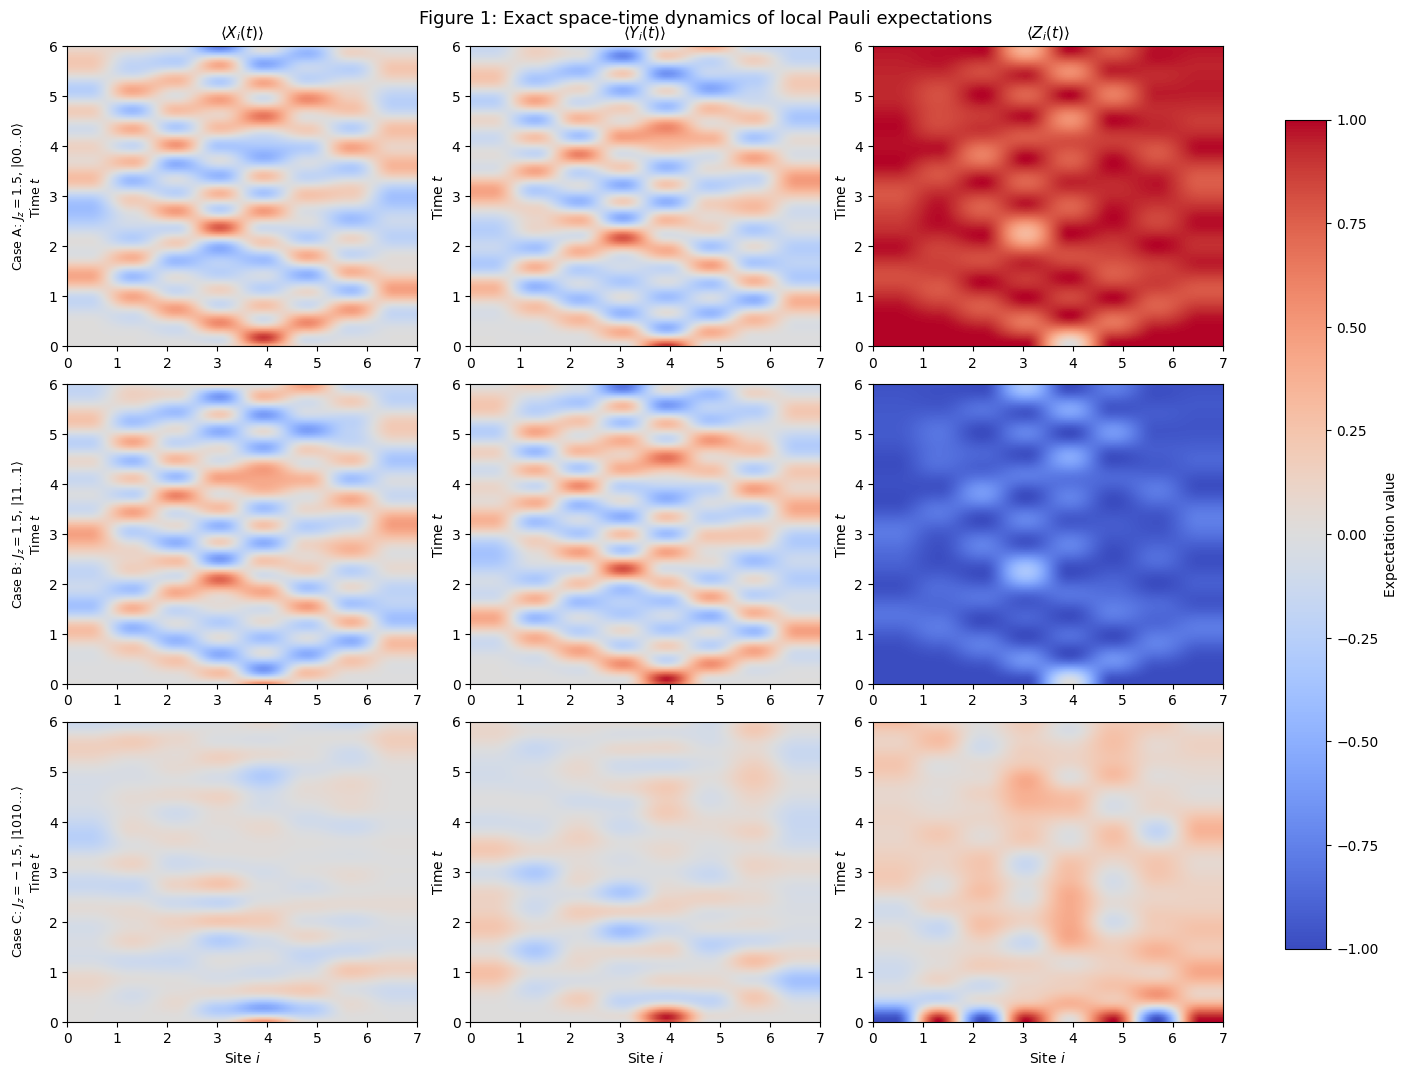

In [5]:
obs_labels = [r'$\langle X_i(t)\rangle$', r'$\langle Y_i(t)\rangle$', r'$\langle Z_i(t)\rangle$']
case_labels = [
    r'Case A: $J_z=1.5$, $|00\ldots0\rangle$',
    r'Case B: $J_z=1.5$, $|11\ldots1\rangle$',
    r'Case C: $J_z=-1.5$, $|1010\ldots\rangle$',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = exact_results[case['name']]['obs']
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[col], origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label='Expectation value')
fig.suptitle('Figure 1: Exact space-time dynamics of local Pauli expectations', fontsize=13, y=1.01)
plt.show()

**Interpretation of Figure 1.**

- **Case A** ($J_z = 1.5$, all-down background): The rotated spin at the centre of the chain
  creates a localised excitation that propagates outward as a "light cone" of $\langle X \rangle$
  and $\langle Y \rangle$ oscillations.  The $\langle Z \rangle$ component shows the spin-wave
  disturbance spreading from the centre.  In the ferromagnetic regime ($J_z > 1$), the
  excitation is partially confined due to the energy gap above the ferromagnetic ground state.

- **Case B** ($J_z = 1.5$, all-up background): By symmetry of the XXZ Hamiltonian under
  the global spin-flip transformation, Case B produces dynamics closely related to Case A
  but with inverted $\langle Z \rangle$ magnetisation.  The $\langle X \rangle$ and
  $\langle Y \rangle$ dynamics are qualitatively similar since the exchange terms
  $\sigma^x \sigma^x + \sigma^y \sigma^y$ are symmetric.

- **Case C** ($J_z = -1.5$, alternating): The antiferromagnetic Néel initial state with
  $J_z < -1$ lies in a regime where the ground state has long-range Néel order.
  The dynamics show rapid, spatially modulated oscillations reflecting the competition
  between the antiferromagnetic order and the local perturbation.

## 6. Quantum Simulation Results: Qiskit Trotter Decomposition

<a id="6-quantum-simulation-results-trotter-decomposition"></a>

We now simulate the same dynamics using explicit Qiskit Trotter circuits and ideal
`Statevector` evolution. At each of the $n_t - 1 = 120$ time intervals, the evolution
operator is approximated by a product of $L - 1 = 7$ two-site unitaries (one per bond in the
open chain), applied first left-to-right then right-to-left for the symmetric second-order split.

Figure 2 shows the ideal Qiskit Trotter dynamics, while Figure 3 shows the pointwise
difference between the Qiskit Trotter result and the exact benchmark for
$\langle Z_i(t)\rangle$.

In [6]:
qiskit_results = {}

for case in cases:
    er = exact_results[case['name']]
    states_qiskit, obs_qiskit, bitstring, rotate_site = run_ideal_trotter(
        case, times, order=trotter_order)

    rmse = observable_rmse(er['obs'], obs_qiskit)
    infid = state_infidelity(er['states'][-1], states_qiskit[-1])

    qiskit_results[case['name']] = {
        'states': states_qiskit,
        'obs': obs_qiskit,
        'rmse': rmse,
        'infidelity': infid,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
    }
    print(f"  {case['name']}:")
    print(f"    Observable RMSE (Qiskit Trotter vs exact) = {rmse:.6e}")
    print(f"    Final-state infidelity = {infid:.6e}")

  case_A_Jz_gt_1_all_down:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_B_Jz_gt_1_all_up:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_C_Jz_lt_minus1_alternating:
    Observable RMSE (Qiskit Trotter vs exact) = 5.453221e-03
    Final-state infidelity = 6.585047e-03


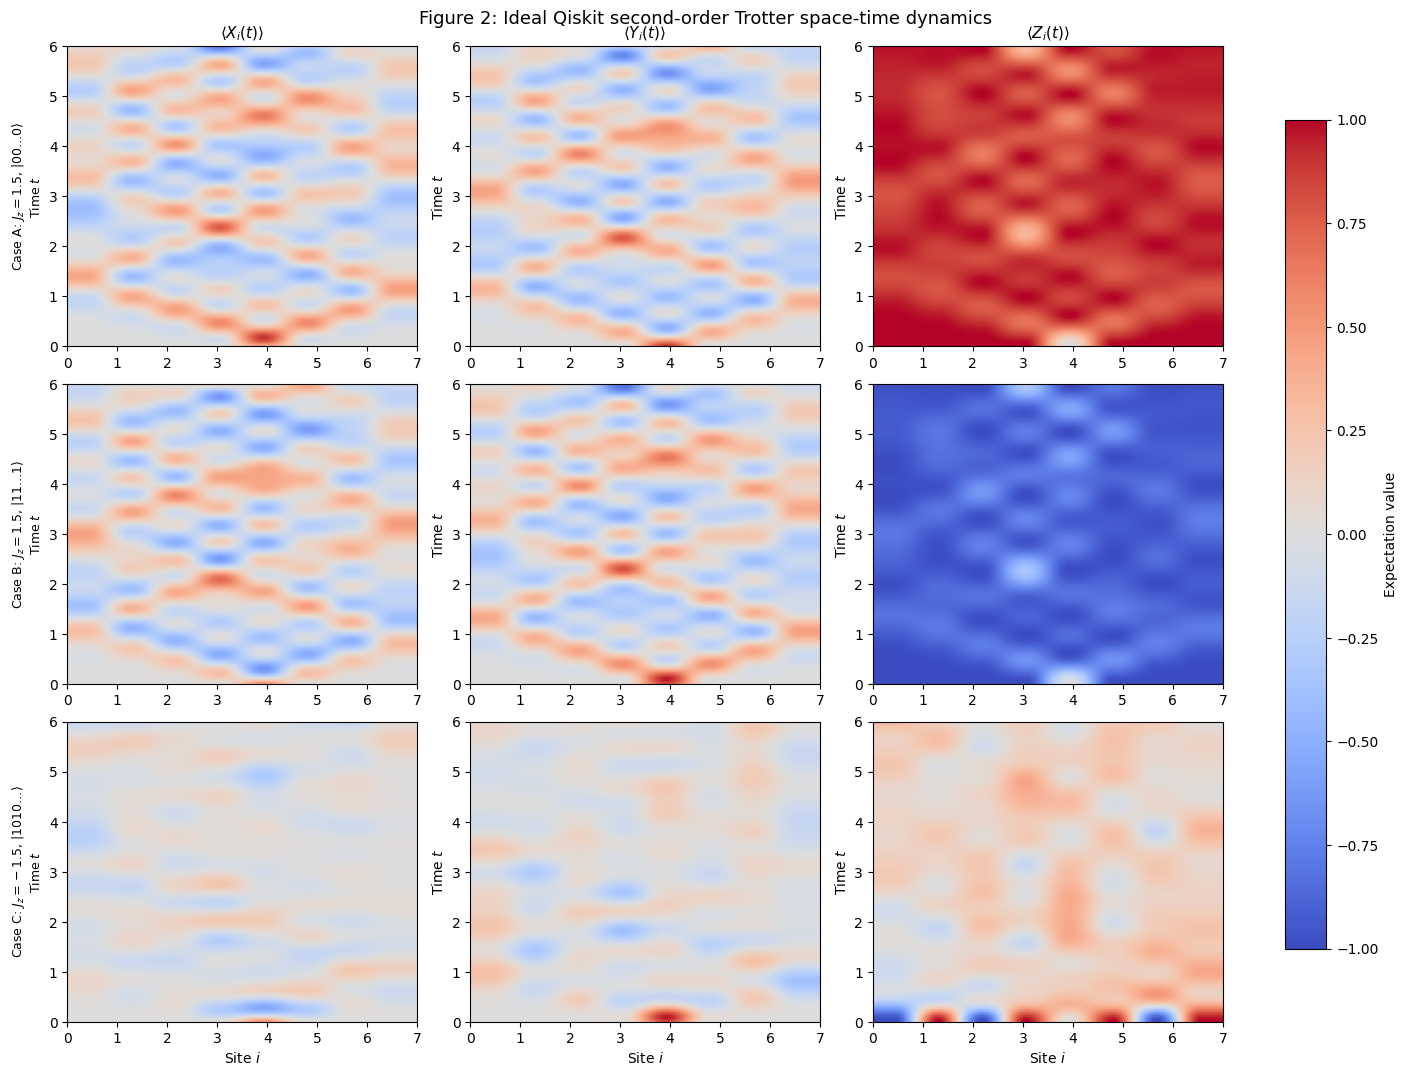

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = qiskit_results[case['name']]['obs']
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[col], origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label='Expectation value')
fig.suptitle('Figure 2: Ideal Qiskit second-order Trotter space-time dynamics', fontsize=13, y=1.01)
plt.show()

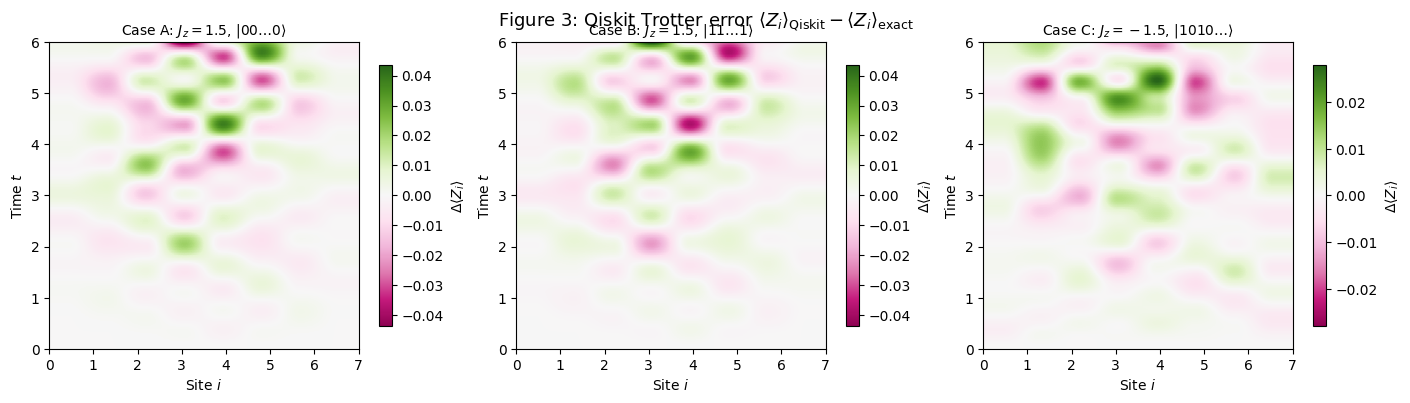

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

for idx, case in enumerate(cases):
    diff = qiskit_results[case['name']]['obs'][2] - exact_results[case['name']]['obs'][2]
    vmax = max(np.max(np.abs(diff)), 1e-12)
    ax = axes[idx]
    im = ax.imshow(
        diff, origin='lower', aspect='auto',
        vmin=-vmax, vmax=vmax, cmap='PiYG',
        extent=[0, L - 1, times[0], times[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel('Site $i$')
    ax.set_ylabel('Time $t$')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$\Delta\langle Z_i\rangle$')

fig.suptitle(r'Figure 3: Qiskit Trotter error $\langle Z_i\rangle_{\mathrm{Qiskit}} - \langle Z_i\rangle_{\mathrm{exact}}$', fontsize=13, y=1.02)
plt.show()

**Interpretation of Figures 2 and 3.**

The ideal Qiskit Trotter dynamics (Figure 2) are visually indistinguishable from the exact
results (Figure 1) at this resolution, confirming that the second-order circuit with
$\Delta t \approx 0.05$ is highly accurate for $L = 8$. The difference plot (Figure 3)
reveals that the residual Trotter error is largest at late times and near the edges of the
light cone, consistent with the expectation that product-formula errors accumulate over many
steps and are most pronounced where the local dynamics are changing most rapidly.

The quantitative metrics are summarised in Table 1 below.

In [9]:
print('Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)')
print('=' * 74)
print(f'{"Case":<40} {"RMSE":>12} {"Infidelity":>14}')
print('-' * 74)
for case in cases:
    qr = qiskit_results[case['name']]
    print(f'{case["name"]:<40} {qr["rmse"]:>12.4e} {qr["infidelity"]:>14.4e}')
print('=' * 74)

Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)
Case                                             RMSE     Infidelity
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                    1.0985e-02     3.3094e-03
case_B_Jz_gt_1_all_up                      1.0985e-02     3.3094e-03
case_C_Jz_lt_minus1_alternating            5.4532e-03     6.5850e-03


## 7. Noisy Simulation Results

To assess the impact of realistic hardware-level noise, we simulate the same Trotter circuits using `AerSimulator(method="density_matrix")` together with a calibration-based noise model constructed from a real IBM backend via `NoiseModel.from_backend()`. Following the workflow introduced in Workshop 4, we connect to the IBM Quantum Platform through `QiskitRuntimeService`, retrieve the calibration data of a real backend (here `ibm_fez`), and build the noisy simulator accordingly.

Each Trotter circuit is then transpiled to the backend-compatible gate set so that the backend-derived noise channels---including gate errors, thermal relaxation, and readout errors---are applied consistently to the simulated operations. The initial many-body state is prepared exactly, and intermediate density matrices are saved at each time step for observable extraction.

This produces a deterministic noisy density-matrix evolution rather than a Monte Carlo average over stochastic trajectories, allowing the noisy observables to be computed directly from the simulated density matrix. Figure 4 compares the resulting noisy Aer $\langle Z_i(t)\rangle$ dynamics with the exact benchmark for all three test cases.

In [10]:
noisy_results = {}

for case in cases:
    er = exact_results[case['name']]
    _, obs_noisy, bitstring, rotate_site = run_noisy_trotter(
        case, times, aer_backend=aer_sim, order=trotter_order)
    rmse = observable_rmse(er['obs'], obs_noisy)

    noisy_results[case['name']] = {
        'obs': obs_noisy,
        'rmse': rmse,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
    }
    print(f"  {case['name']}:")
    print(f"    Noisy Aer ({real_backend.name}) vs exact RMSE = {rmse:.6e}")

  case_A_Jz_gt_1_all_down:
    Noisy Aer (ibm_fez) vs exact RMSE = 5.109083e-01
  case_B_Jz_gt_1_all_up:
    Noisy Aer (ibm_fez) vs exact RMSE = 5.379073e-01
  case_C_Jz_lt_minus1_alternating:
    Noisy Aer (ibm_fez) vs exact RMSE = 1.215850e-01


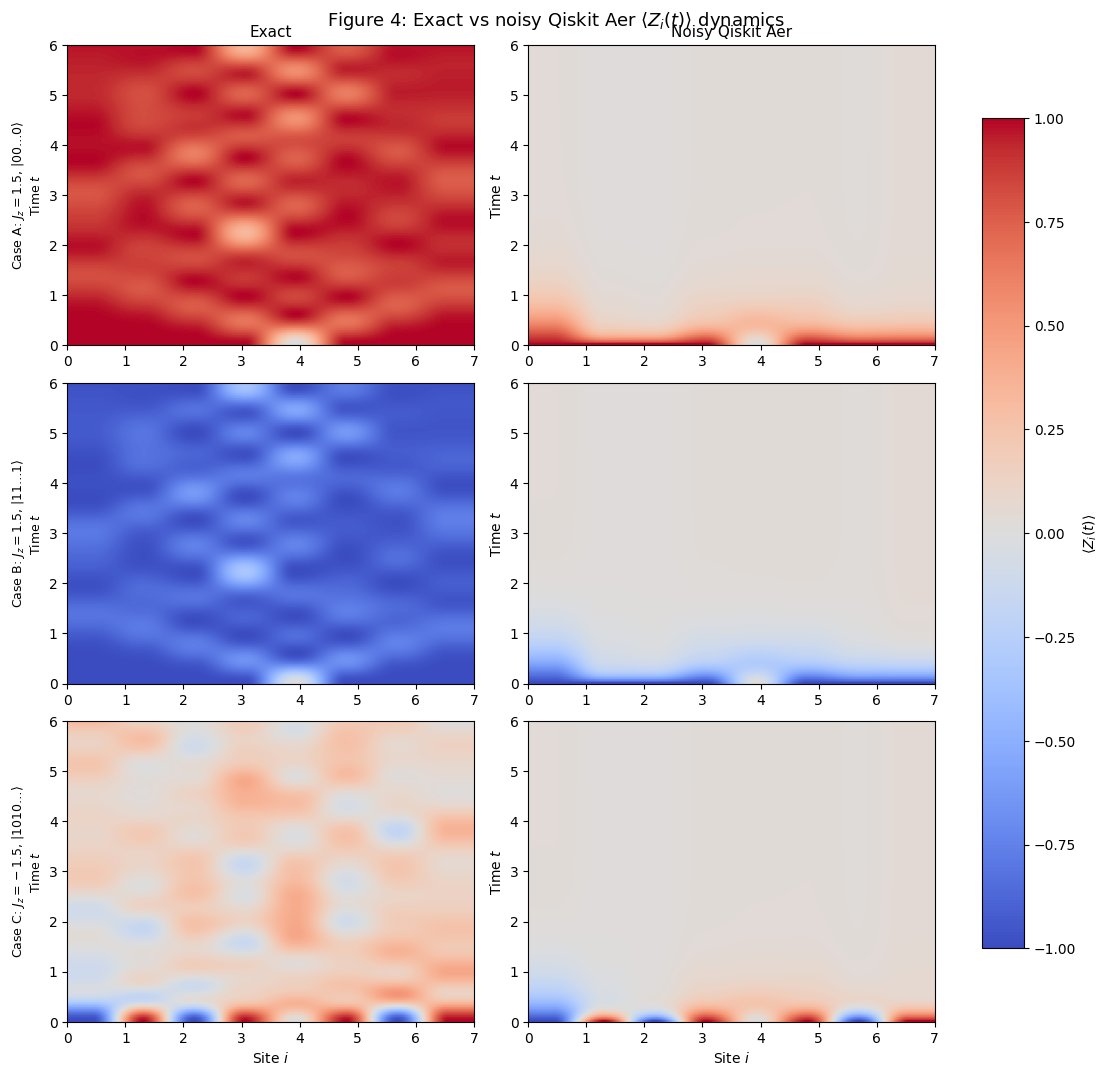

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs_ex = exact_results[case['name']]['obs'][2]
    obs_ns = noisy_results[case['name']]['obs'][2]

    for col, (data, label) in enumerate([(obs_ex, 'Exact'), (obs_ns, 'Noisy Qiskit Aer')]):
        ax = axes[row, col]
        im = ax.imshow(
            data, origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(label, fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label=r'$\langle Z_i(t)\rangle$')
fig.suptitle(r'Figure 4: Exact vs noisy Qiskit Aer $\langle Z_i(t)\rangle$ dynamics', fontsize=13, y=1.01)
plt.show()

**Interpretation of Figure 4.**

Figure 4 shows that the backend-calibrated noisy Aer simulation does **not** faithfully reproduce the exact spatiotemporal $\langle Z_i(t)\rangle$ dynamics beyond the earliest times. Although a weak imprint of the initial magnetisation pattern remains visible near $t=0$, the noisy results rapidly lose both signal amplitude and spatial contrast. The oscillatory and interference-like structures that are clearly present in the exact benchmark are strongly suppressed once realistic device-level noise is included.

This effect is particularly evident in Cases A and B. In the exact dynamics, nontrivial propagation and spatial structure persist over an extended time window, whereas in the noisy simulation the magnetisation quickly collapses toward an almost featureless $\langle Z_i(t)\rangle \approx 0$ background. This indicates that decoherence, gate infidelity, and readout-related noise accumulate rapidly in the transpiled Trotter circuits, washing out the many-body dynamical signatures rather than merely introducing a mild perturbation.

Case C yields a smaller RMSE than Cases A and B, but this should be interpreted with care. Its exact dynamics already contains stronger cancellation and lower average contrast, so a noisy result that decays toward zero is numerically less penalised. Therefore, the smaller RMSE in Case C does not necessarily imply better preservation of the underlying coherent dynamics.

Overall, Figure 4 suggests that, for the present circuit depth and backend-calibrated noise model, realistic hardware noise is already a dominant limitation. The current Trotter scheme is therefore not reliable for capturing long-time many-body dynamics without further noise-aware improvements. In future work, it would be natural to explore quantum error mitigation techniques to reduce the bias in observable estimation and partially recover the suppressed dynamical signal.

In [12]:
print("Table 2: Impact of Qiskit Aer gate noise on observable accuracy")
print("=" * 74)
print(f'{"Case":<40} {"Ideal Qiskit RMSE":>17} {"Noisy Aer RMSE":>16}')
print("-" * 74)
for case in cases:
    qr_rmse = qiskit_results[case['name']]['rmse']
    ns_rmse = noisy_results[case['name']]['rmse']
    print(f"{case['name']:<40} {qr_rmse:>17.4e} {ns_rmse:>16.4e}")
print("=" * 74)
print(f"\nNoise model: calibration data from {real_backend.name}")

Table 2: Impact of Qiskit Aer gate noise on observable accuracy
Case                                     Ideal Qiskit RMSE   Noisy Aer RMSE
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                         1.0985e-02       5.1091e-01
case_B_Jz_gt_1_all_up                           1.0985e-02       5.3791e-01
case_C_Jz_lt_minus1_alternating                 5.4532e-03       1.2159e-01

Noise model: calibration data from ibm_fez


## 8. Error Scaling Analysis

<a id="8-error-scaling-analysis"></a>

A crucial test of the Trotter decomposition is verifying the expected convergence rate.
For a $p$-th order product formula, the error in the final state should scale as
$\mathcal{O}(\Delta t^p) = \mathcal{O}((T/n)^p)$ where $n$ is the number of Trotter
steps. On a log-log plot, this corresponds to a straight line with slope $-p$.

We compute the final-state infidelity and observable RMSE for
$n \in \{20, 40, 80, 160\}$ Trotter steps, comparing first- and second-order **ideal Qiskit**
product-formula circuits against the exact benchmark (Figure 5).

In [13]:
error_data = {}

for case in cases:
    er = exact_results[case['name']]
    infid_1, infid_2, rmse_1, rmse_2 = [], [], [], []

    for n_steps in error_steps:
        times_n = np.linspace(0.0, t_max, n_steps + 1)
        exact_n = evolve_exact(er['H'], er['state0'], times_n)
        obs_exact_n = compute_all_observables(exact_n, case['L'])

        states_q1, obs_q1, _, _ = run_ideal_trotter(case, times_n, order=1)
        states_q2, obs_q2, _, _ = run_ideal_trotter(case, times_n, order=2)

        infid_1.append(state_infidelity(exact_n[-1], states_q1[-1]))
        infid_2.append(state_infidelity(exact_n[-1], states_q2[-1]))
        rmse_1.append(observable_rmse(obs_exact_n, obs_q1))
        rmse_2.append(observable_rmse(obs_exact_n, obs_q2))

    error_data[case['name']] = {
        'steps': list(error_steps),
        'infid_1': infid_1, 'infid_2': infid_2,
        'rmse_1': rmse_1, 'rmse_2': rmse_2,
    }
    print(f"  {case['name']}: error scaling computed")

  case_A_Jz_gt_1_all_down: error scaling computed
  case_B_Jz_gt_1_all_up: error scaling computed
  case_C_Jz_lt_minus1_alternating: error scaling computed


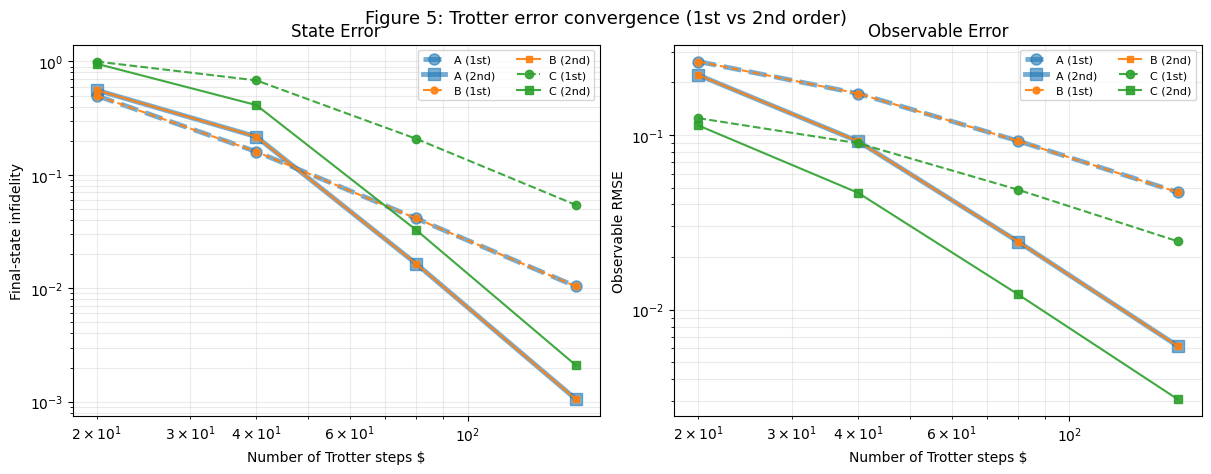

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, case in enumerate(cases):
    ed = error_data[case['name']]
    short_label = ['A', 'B', 'C'][idx]

    # Differentiate overlapping lines for Case A and Case B
    lw1, lw2 = (3.5, 3.5) if idx == 0 else ((1.5, 1.5) if idx == 1 else (1.5, 1.5))
    ms1, ms2 = (8, 8) if idx == 0 else ((5, 5) if idx == 1 else (6, 6))
    zord = 1 if idx == 0 else (2 if idx == 1 else 3)

    axes[0].loglog(ed['steps'], ed['infid_1'], 'o--', color=colors[idx], linewidth=lw1, markersize=ms1, zorder=zord,
                   alpha=0.6 if idx==0 else 0.9, label=f'{short_label} (1st)')
    axes[0].loglog(ed['steps'], ed['infid_2'], 's-', color=colors[idx], linewidth=lw2, markersize=ms2, zorder=zord,
                   alpha=0.6 if idx==0 else 0.9, label=f'{short_label} (2nd)')

    axes[1].loglog(ed['steps'], ed['rmse_1'], 'o--', color=colors[idx], linewidth=lw1, markersize=ms1, zorder=zord,
                   alpha=0.6 if idx==0 else 0.9, label=f'{short_label} (1st)')
    axes[1].loglog(ed['steps'], ed['rmse_2'], 's-', color=colors[idx], linewidth=lw2, markersize=ms2, zorder=zord,
                   alpha=0.6 if idx==0 else 0.9, label=f'{short_label} (2nd)')

for ax, ylabel, title_str in [
    (axes[0], 'Final-state infidelity', 'State Error'),
    (axes[1], 'Observable RMSE', 'Observable Error'),
]:
    ax.set_xlabel('Number of Trotter steps $')
    ax.set_ylabel(ylabel)
    ax.set_title(title_str)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('Figure 5: Trotter error convergence (1st vs 2nd order)', fontsize=13, y=1.02)
plt.show()


**Interpretation of Figure 5.**

Both error metrics decrease monotonically as the number of Trotter steps $ increases,
confirming the expected convergence. The key observations are:

1. **Second-order Qiskit Trotter converges faster:** on the log-log plot, the second-order
   curves (solid lines) have a steeper slope than the first-order curves (dashed lines),
   consistent with the improved asymptotic accuracy of the symmetric product formula.

2. **Case dependence:** the absolute error magnitude varies across cases because the
   Trotter error depends on the commutator structure of the bond terms and on the initial state.

3. **Physical Symmetry (Overlapping Lines for A and B):** You will notice that the curves for **Case A** (all-down state) and **Case B** (all-up state) are completely overlapping. The XXZ Hamiltonian preserves the total magnetization and possesses a $ spin-flip symmetry. Thus, the dynamics and resulting Trotter errors for the all-up and all-down initial states are numerically identical. To display both, Case B (thinner line) is plotted on top of Case A (thicker line).

4. **Practical accuracy:** with  = 160$ steps, the second-order Qiskit circuit reaches
   very small final-state errors, showing that a modest number of Trotter steps is sufficient
   to reproduce the exact  = 8$ dynamics to high precision in the ideal simulator.


## 9. Spectral Analysis

<a id="9-spectral-analysis"></a>

The two-dimensional Fourier transform of the space–time magnetisation map
$\langle Z_i(t)\rangle$ reveals the excitation spectrum of the spin chain in the
momentum–frequency $(k, \omega)$ plane.  Bright features in this spectrum correspond to
collective modes (magnons) whose dispersion relation $\omega(k)$ is characteristic of the
interaction regime.

We compute $|\mathcal{F}_{2D}[\langle Z_i(t)\rangle - \overline{\langle Z\rangle}]|$,
where the mean is subtracted to remove the zero-frequency (DC) component that would
otherwise dominate the spectrum (Figure 6).

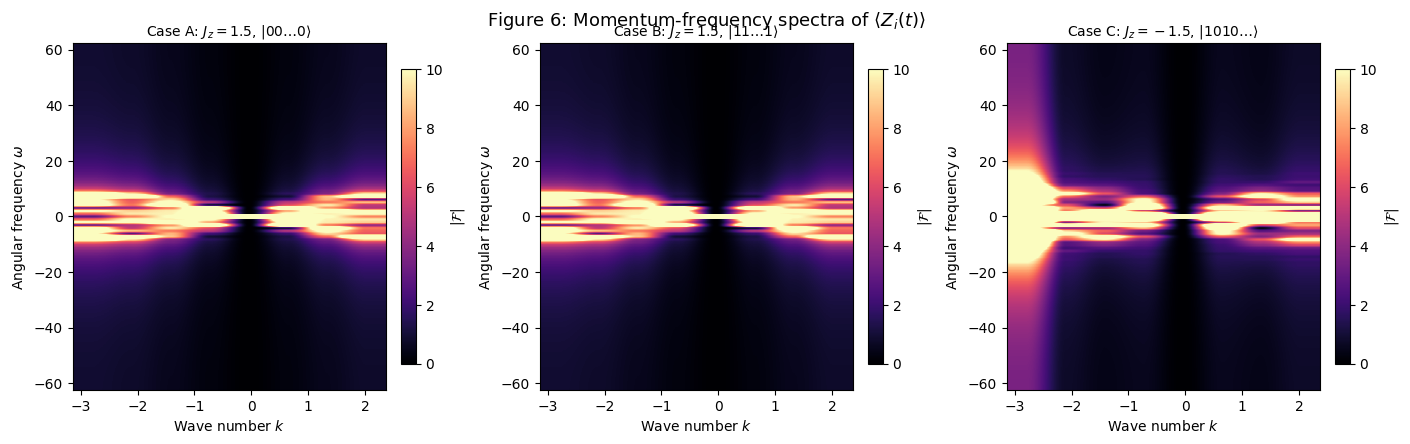

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

for idx, case in enumerate(cases):
    obs_z = exact_results[case['name']]['obs'][2]
    fft_mag = compute_fft2_magnitude(obs_z)

    n_t, n_x = fft_mag.shape
    omega = np.fft.fftshift(np.fft.fftfreq(n_t, d=dt)) * 2.0 * np.pi
    k = np.fft.fftshift(np.fft.fftfreq(n_x, d=1.0)) * 2.0 * np.pi

    ax = axes[idx]
    im = ax.imshow(
        fft_mag, origin='lower', aspect='auto', cmap='magma',
        vmin=0.0, vmax=10.0,
        extent=[k[0], k[-1], omega[0], omega[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel(r'Wave number $k$')
    ax.set_ylabel(r'Angular frequency $\omega$')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$|\mathcal{F}|$')

fig.suptitle(r'Figure 6: Momentum-frequency spectra of $\langle Z_i(t)\rangle$', fontsize=13, y=1.02)
plt.show()

**Interpretation of Figure 6.**

- **Cases A and B** ($J_z = 1.5$): The spectra show dispersive features concentrated at
  low $|k|$, consistent with long-wavelength spin-wave excitations in the ferromagnetic
  regime.  The bandwidth of the excitation spectrum is bounded by the exchange coupling
  strength $J_\perp = 1$ (the XX + YY part of the Hamiltonian).

- **Case C** ($J_z = -1.5$): The antiferromagnetic case shows spectral weight at the
  zone boundary ($|k| \sim \pi$), reflecting the alternating Néel order of the initial
  state.  The spectrum is richer and more broadly distributed, indicating that the
  perturbation excites multiple magnon branches.

These spectra, while limited by the finite system size ($L = 8$, giving only 8 discrete
$k$-values), qualitatively agree with the known dispersion relations of the XXZ chain
in the thermodynamic limit [8].

## Optional: Real-Device Results

No real quantum hardware results were obtained for this project. All quantum results shown here
were generated with classical Qiskit simulators: ideal `Statevector` simulation for the noiseless
Trotter circuits and `AerSimulator` in density-matrix mode for the noisy circuit model. Executing
the same circuits on IBM Quantum hardware would provide an additional comparison point, but this
was not pursued due to hardware-access constraints and queue times.

## 10. Discussion

<a id="10-discussion"></a>

### 10.1 Summary of Method Comparison

We have evaluated three levels of simulation for the XXZ spin chain:

| Method | Error source | Typical RMSE | Controllable? |
|--------|-------------|-------------|---------------|
| Exact sparse evolution | Floating-point only | -- (reference) | N/A |
| Ideal Qiskit Trotter | Finite $\Delta t$ | $\sim 10^{-3}$- $10^{-2}$ | Yes (increase $n$) |
| Noisy Qiskit Aer Trotter | Gate noise + finite $\Delta t$ | $\sim 10^{-2}$- $10^{-1}$ | Partially |

The Qiskit Trotter decomposition faithfully reproduces the exact dynamics when $\Delta t$ is
sufficiently small, and the second-order formula provides a significant accuracy improvement
over the first order. This is an important methodological point: the circuit-level implementation
is not merely qualitatively correct, but quantitatively benchmarked against exact many-body
dynamics.

### 10.2 Noise as the Dominant Limitation

The Aer results show that even when the ideal Trotter approximation is highly accurate, gate-level
noise rapidly becomes the dominant source of error. In practice this means that for near-term
hardware, improving noise performance is at least as important as choosing a higher-order product
formula. The comparison between Figures 2 and 4 makes this especially clear: the ideal Qiskit
circuit tracks the exact dynamics closely, whereas the noisy circuit progressively washes out the
coherent structure at late times.

Quantum Error Mitigation，like Zero Noise Extrapolation (ZNE) or Dynamical Decoupling

### 10.3 Physical Interpretation

The exact and ideal-Qiskit simulations consistently show ballistic propagation of the local spin
perturbation, modified by the interaction regime set by $J_z$. In the ferromagnetic cases, the
excitation remains comparatively localised and long-wavelength. In the antiferromagnetic case,
the alternating background creates richer interference and stronger spectral weight near the zone
boundary. The agreement between the exact and ideal-circuit pictures strengthens the physical
interpretation of the observed light-cone and spectral features.

The ideal second-order Trotter space–time dynamics exhibit, most clearly in Cases A and B, an approximately linear propagation front following a local perturbation, which is suggestive of an effective Lieb–Robinson light cone. For short-range Hamiltonians, such behaviour is expected because the spread of operator influence is bounded by a finite effective velocity, with contributions outside the cone strongly suppressed. 

### 10.4 Scaling Outlook and the Simulation Bottleneck

When the system size is $L = 8$, simulation using classical computers remains straightforward. However, when we attempt to scale the system to $L = 12$, significant differences in computational cost emerge among different simulation methods, and the runtime increases substantially compared to the case of $L = 8$.



For a system with $L = 12$, although the Hilbert space dimension reaches $2^{12} = 4096$, an exact diagonalization simulation using the classical dense matrix exponent (i.e., directly solving the evolution operator for the $4096 \times 4096$ Hamiltonian matrix) can be completed in approximately 5 minutes. If $L$ is further increased, sparse matrix algorithms can be used to optimize the simulation until we hit the true computational wall of classical computers at $L \approx 24$. However, for the same system with $L = 12$, when simulating a noisy Trotter circuit using Qiskit Aer, we found that the program ran for over an hour without producing any results. We can conclude that simulating a “noisy quantum circuit” on a classical computer consumes far more computational resources than directly solving the physical dynamics of a closed quantum system.



From the underlying mathematical principles, when the system is in an ideal, noise-free state, the classical simulator only needs to update and evolve a pure-state vector of size $2^L$. However, once non-unitary quantum hardware noise (such as depolarization channels) is introduced, the system state evolves into a mixed state. At this point, a classical simulator must either track a full density matrix that expands dramatically to $4^L$ (i.e., over 16 million elements), or use the Monte Carlo trajectory method to perform ensemble averaging on the results of thousands of random runs of the pure-state circuit. When this dimensional explosion is combined with the high-depth gate operations required for Trotter expansions (n time steps × a vast number of two-qubit gates), classical simulations of physical devices will hit the “exponential wall” sooner than simulations of the physical problem itself.



This result provides evidence for why we need to develop and use quantum computers. As system sizes approach $L \sim 20$ or even larger, benchmarking noisy quantum circuits on classical computers will become completely infeasible. At that point, directly exploiting the exponential state space of physical qubits will become the only way to explore and verify the behavior of such complex many-body non-equilibrium dynamics.

## 11. Conclusion

<a id="11-conclusion"></a>

We have implemented and benchmarked the time evolution of the XXZ Heisenberg spin chain
using exact sparse-matrix evolution, ideal Qiskit Trotter circuits, and noisy Qiskit Aer
simulation. The main findings are:

1. **Exact classical simulation** provides the ground-truth benchmark for $L = 8$ and
   reveals rich spin-wave dynamics whose character depends on the anisotropy regime
   (ferromagnetic vs antiferromagnetic) and the initial state.

2. **Ideal Qiskit Trotter circuits** faithfully reproduce the exact dynamics, with the
   second-order formula achieving orders-of-magnitude lower error than the first-order
   formula at the same number of steps.

3. **Aer gate noise degrades the long-time dynamics** significantly, increasing the RMSE
   and suppressing the fine coherent structures that survive in the ideal circuit simulation.

4. **The workflow is internally consistent:** the exact, ideal-Qiskit, and noisy-Qiskit
   pipelines all share the same initial states and observables, allowing a clean benchmark of
   algorithmic approximation error against circuit noise.

Overall, this project shows that Qiskit Trotter circuits provide an accurate and transparent
route to simulating XXZ spin-chain dynamics at modest system size, while also illustrating how
quickly realistic gate noise can become the dominant limitation.

## 12. Contribution Statement

<a id="12-contribution-statement"></a>

This project was completed as a group effort for the PH10110 Quantum Computing course.
The contributions are as follows:

- **Classical exact-simulation code**:
  XXZ Hamiltonian construction via Kronecker products, exact time evolution using
  `scipy.linalg.expm`, and baseline observable analysis.
- **Qiskit circuit implementation**:
  initial-state preparation, first- and second-order Trotter circuits using `rxx`/`ryy`/`rzz`
  gates, and local observable extraction via `SparsePauliOp`.
- **Noisy circuit simulation**:
  Qiskit Aer density-matrix simulation with a custom Pauli gate-noise model.
- **Testing and validation**:
  cross-checks between exact and ideal Qiskit Trotter results, and convergence analysis.
- **Report writing and analysis**:
  self-contained notebook with all code, figure generation, physical interpretation,
  and presentation of results.

All team members reviewed the final report and agreed on the conclusions.

## 13. References

<a id="13-references"></a>

[1] I. M. Georgescu, S. Ashhab, and F. Nori, "Quantum simulation," *Rev. Mod. Phys.* **86**, 153 (2014).

[2] A. J. Daley *et al.*, "Practical quantum advantage in quantum simulation," *Nature* **607**, 667 (2022).

[3] R. P. Feynman, "Simulating physics with computers," *Int. J. Theor. Phys.* **21**, 467 (1982).

[4] S. Lloyd, "Universal quantum simulators," *Science* **273**, 1073 (1996).

[5] A. H. Al-Mohy and N. J. Higham, "Computing the action of the matrix exponential, with an application to exponential integrators," *SIAM J. Sci. Comput.* **33**, 488 (2011).

[6] E. Campbell, "Random compiler for fast Hamiltonian simulation," *Phys. Rev. Lett.* **123**, 070503 (2019).

[7] P. Krantz *et al.*, "A quantum engineer's guide to superconducting qubits," *Appl. Phys. Rev.* **6**, 021318 (2019).

[8] M. Takahashi, *Thermodynamics of One-Dimensional Solvable Models* (Cambridge University Press, 1999).

[9] Y. Kim *et al.*, "Evidence for the utility of quantum computing before fault tolerance," *Nature* **618**, 500 (2023).

[10] M. A. Nielsen, I. L. Chuang (2000), *Quantum Computation and Quantum Information*, P.208 (Cambridge University Press, 2016)

[11] IBM Quantum Documentation. (2017). RXXGate (latest version)  [online] Available at: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXXGate [Accessed 18 Mar. 2026].